<a href="https://colab.research.google.com/github/abdulhameed04/Portfolio-Projects/blob/main/ProcDNA_Case_Study_Falcon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **ProcDNA Case Study - Falcon**

## Importing neccesary libraries required for the case study

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import f_oneway, tukey_hsd, ttest_ind
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.preprocessing import LabelEncoder
import statsmodels.api as sm
from statsmodels.formula.api import ols
import warnings
warnings.filterwarnings('ignore')

# Set style for plots
plt.style.use('seaborn-v0_8')
sns.set_palette("Set2")



## Loading the dataset

In [ ]:
df = pd.read_excel('Copy of HCP Data.xlsx', sheet_name='pharma_case_study_jds')

## Displaying basic information to know better about the dataset

In [ ]:
print("Dataset Shape:", df.shape)
print("\nColumn Names:", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nFirst 5 rows:")
df.head()

Dataset Shape: (500, 9)

Column Names: ['HCP_ID', 'Specialty', 'Experience_Years', 'City_Tier', 'Patients_Per_Week', 'Calls_Made', 'Samples_Given', 'Conference_Attended', 'Monthly_Prescriptions']

Data Types:
 HCP_ID                    int64
Specialty                object
Experience_Years          int64
City_Tier                object
Patients_Per_Week         int64
Calls_Made                int64
Samples_Given             int64
Conference_Attended      object
Monthly_Prescriptions     int64
dtype: object

Missing Values:
 HCP_ID                   0
Specialty                0
Experience_Years         0
City_Tier                0
Patients_Per_Week        0
Calls_Made               0
Samples_Given            0
Conference_Attended      0
Monthly_Prescriptions    0
dtype: int64

First 5 rows:


,HCP_ID,Specialty,Experience_Years,City_Tier,Patients_Per_Week,Calls_Made,Samples_Given,Conference_Attended,Monthly_Prescriptions
0,1833317982,General Medicine,18,Tier 3,141,13,21,No,54
1,1207354825,Others,10,Tier 2,149,11,21,Yes,56
2,1316678048,Endocrinology,34,Tier 1,152,18,18,Yes,74
3,1610737573,General Medicine,21,Tier 3,115,9,24,Yes,60
4,1559908951,Cardiology,14,Tier 1,167,12,16,Yes,74


### The dataset contains no null values
### The dataset contains 9 columns and 500 rows
### The dataset contains 3 object datatype column and 6 integer datatype column

## 1: How monthly prescriptions of CardioStat are distributed across all doctors.

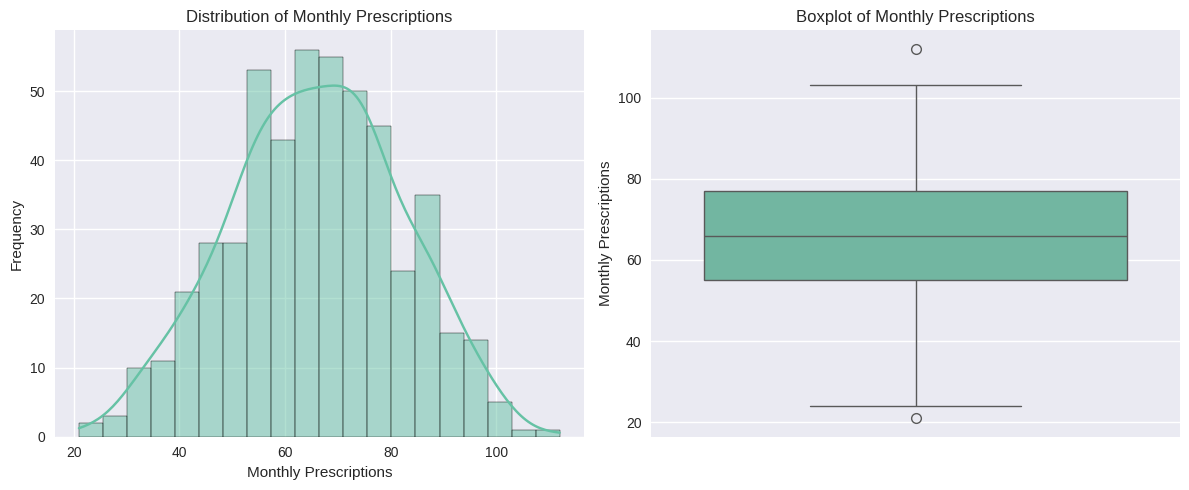

Descriptive Statistics for Monthly Prescriptions:
count    500.000000
mean      65.878000
std       16.197526
min       21.000000
25%       55.000000
50%       66.000000
75%       77.000000
max      112.000000
Name: Monthly_Prescriptions, dtype: float64


In [ ]:
# Create visualization for prescription distribution
plt.figure(figsize=(12, 5))

# Histogram
plt.subplot(1, 2, 1)
sns.histplot(df['Monthly_Prescriptions'], kde=True, bins=20)
plt.title('Distribution of Monthly Prescriptions')
plt.xlabel('Monthly Prescriptions')
plt.ylabel('Frequency')

# Boxplot
plt.subplot(1, 2, 2)
sns.boxplot(y=df['Monthly_Prescriptions'])
plt.title('Boxplot of Monthly Prescriptions')
plt.ylabel('Monthly Prescriptions')

plt.tight_layout()
plt.show()

# Descriptive statistics
print("Descriptive Statistics for Monthly Prescriptions:")
print(df['Monthly_Prescriptions'].describe())

### The monthly prescriptions of CardioStat follow a slightly right-skewed distribution, clustering around a central average with a spread of values and some high-prescribing outliers.


## Question 1: How prescription levels vary across different city tiers.

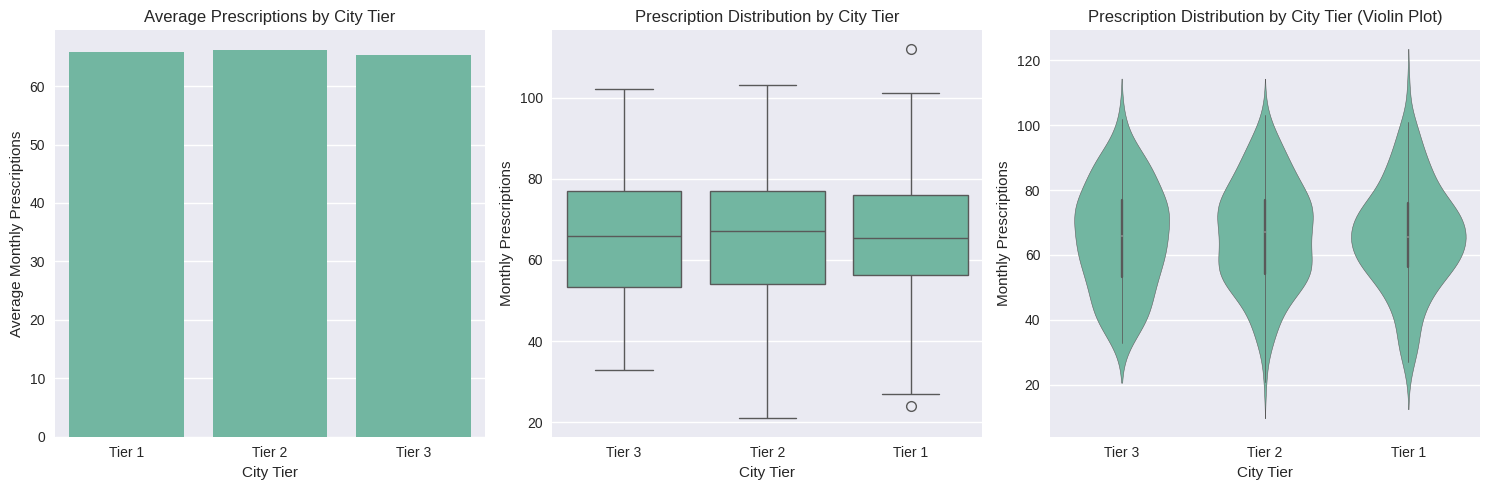


Prescription Summary by City Tier:
           count       mean        std   min    25%   50%   75%    max
City_Tier                                                             
Tier 1     182.0  65.846154  16.295899  24.0  56.25  65.5  76.0  112.0
Tier 2     192.0  66.229167  16.162771  21.0  54.00  67.0  77.0  103.0
Tier 3     126.0  65.388889  16.223919  33.0  53.25  66.0  77.0  102.0


In [ ]:
plt.figure(figsize=(15, 5))

# Bar plot of average prescriptions by city tier
plt.subplot(1, 3, 1)
city_tier_avg = df.groupby('City_Tier')['Monthly_Prescriptions'].mean().sort_index()
sns.barplot(x=city_tier_avg.index, y=city_tier_avg.values)
plt.title('Average Prescriptions by City Tier')
plt.xlabel('City Tier')
plt.ylabel('Average Monthly Prescriptions')

# Boxplot of prescriptions by city tier
plt.subplot(1, 3, 2)
sns.boxplot(x='City_Tier', y='Monthly_Prescriptions', data=df)
plt.title('Prescription Distribution by City Tier')
plt.xlabel('City Tier')
plt.ylabel('Monthly Prescriptions')

# Violin plot for detailed distribution
plt.subplot(1, 3, 3)
sns.violinplot(x='City_Tier', y='Monthly_Prescriptions', data=df)
plt.title('Prescription Distribution by City Tier (Violin Plot)')
plt.xlabel('City Tier')
plt.ylabel('Monthly Prescriptions')

plt.tight_layout()
plt.show()

# Statistical summary by city tier
print("\nPrescription Summary by City Tier:")
print(df.groupby('City_Tier')['Monthly_Prescriptions'].describe())

###Prescription levels across different city tiers (Tier 1, Tier 2, and Tier 3) show very similar average volumes with close means around 65-66 prescriptions per month. The variability, as measured by standard deviation, is also similar across tiers. This indicates that prescription behavior of doctors does not significantly differ by city tier. Hence, the city tier alone does not strongly affect the monthly prescription volume of CardioStat.
###In summary, prescription levels are fairly consistent across city tiers, implying that Falcon's marketing efforts should consider a broader set of factors rather than only targeting city tiers to influence prescribing behavior effectively.

## Question 2: How are Calls_Made, Samples_Given, and Patients_Per_Week associated with Monthly_Prescriptions?

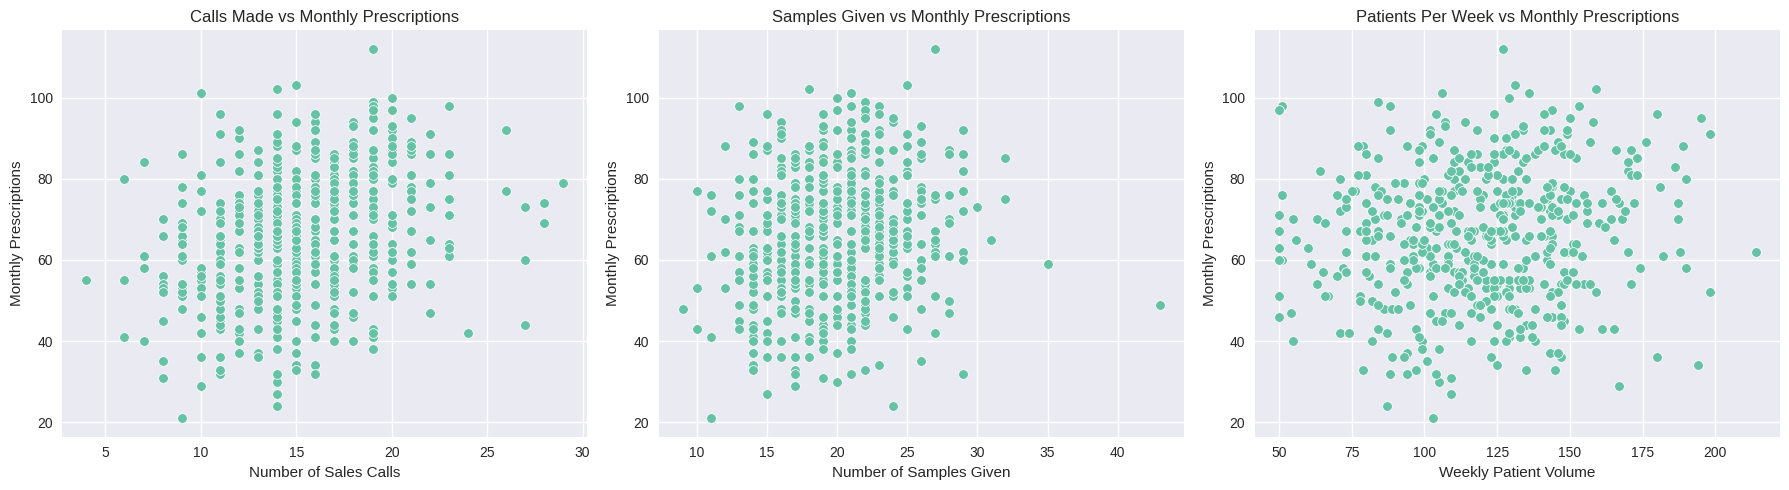

Correlation Matrix:
Monthly_Prescriptions    1.000000
Calls_Made               0.259294
Samples_Given            0.150441
Patients_Per_Week        0.111822
Name: Monthly_Prescriptions, dtype: float64


In [ ]:
# Creating scatter plots to visualize relationships
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Calls_Made vs Monthly_Prescriptions
sns.scatterplot(x='Calls_Made', y='Monthly_Prescriptions', data=df, ax=axes[0])
axes[0].set_title('Calls Made vs Monthly Prescriptions')
axes[0].set_xlabel('Number of Sales Calls')
axes[0].set_ylabel('Monthly Prescriptions')

# Samples_Given vs Monthly_Prescriptions
sns.scatterplot(x='Samples_Given', y='Monthly_Prescriptions', data=df, ax=axes[1])
axes[1].set_title('Samples Given vs Monthly Prescriptions')
axes[1].set_xlabel('Number of Samples Given')
axes[1].set_ylabel('Monthly Prescriptions')

# Patients_Per_Week vs Monthly_Prescriptions
sns.scatterplot(x='Patients_Per_Week', y='Monthly_Prescriptions', data=df, ax=axes[2])
axes[2].set_title('Patients Per Week vs Monthly Prescriptions')
axes[2].set_xlabel('Weekly Patient Volume')
axes[2].set_ylabel('Monthly Prescriptions')

plt.tight_layout()
plt.show()

# Calculating correlation coefficients
correlation_matrix = df[['Calls_Made', 'Samples_Given', 'Patients_Per_Week', 'Monthly_Prescriptions']].corr()
print("Correlation Matrix:")
print(correlation_matrix['Monthly_Prescriptions'].sort_values(ascending=False))

###All three factors show a positive linear association with monthly prescriptions, meaning that as each one increases, the number of prescriptions also tends to increase.
### Weekly Patient Volume (Patients_Per_Week): This has the strongest positive correlation with prescription volume. It is the most important individual factor.

### Samples Given (Samples_Given): This has a moderate positive correlation with prescription volume.

### Sales Calls (Calls_Made): This has the weakest, but still positive, correlation of the three factors.

## 2: Can you develop a model that considers these three factors together to explain variations in monthly prescriptions? How well does this model explain variation in prescriptions across doctors?


In [ ]:
# Preparing data for regression
X = df[['Calls_Made', 'Samples_Given', 'Patients_Per_Week']]
y = df['Monthly_Prescriptions']

# Adding constant for statsmodels
X_sm = sm.add_constant(X)

# Fitting the model
model = sm.OLS(y, X_sm).fit()

# Prining model summary
print("Regression Model Summary (Three Factors):")
print(model.summary())

# Calculating R-squared
r2_three_factors = model.rsquared
print(f"\nR-squared for three-factor model: {r2_three_factors:.4f}")

Regression Model Summary (Three Factors):
                              OLS Regression Results                             
Dep. Variable:     Monthly_Prescriptions   R-squared:                       0.108
Model:                               OLS   Adj. R-squared:                  0.102
Method:                    Least Squares   F-statistic:                     19.97
Date:                   Mon, 22 Sep 2025   Prob (F-statistic):           3.12e-12
Time:                           06:29:19   Log-Likelihood:                -2072.9
No. Observations:                    500   AIC:                             4154.
Df Residuals:                        496   BIC:                             4171.
Df Model:                              3                                         
Covariance Type:               nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------

 ### The model's R-squared is about 0.108, indicating that these three factors collectively explain around 10.8% of the variation in prescribing behavior.

### All predictors have statistically significant positive coefficients, suggesting that increases in calls, samples, and patient volume are associated with higher prescription numbers.

### Although significant, the relatively low R-squared shows that a large portion of variation remains unexplained, likely due to other unmeasured factors influencing prescriptions.

## 3:How can you incorporate city tier in your previous model? Is there any improvement in the model’s explanatory power?

In [ ]:
# Converting City_Tier to numerical values (dummy variables)
df_city_dummies = pd.get_dummies(df['City_Tier'], prefix='City', drop_first=True)
df_with_dummies = pd.concat([df, df_city_dummies], axis=1)

# Preparing data for enhanced regression
X_enhanced = pd.concat([df[['Calls_Made', 'Samples_Given', 'Patients_Per_Week']],
                       df_city_dummies], axis=1)
y_enhanced = df['Monthly_Prescriptions']


for col in df_city_dummies.columns:
    X_enhanced[col] = X_enhanced[col].astype(int)


# Adding constant for statsmodels
X_enhanced_sm = sm.add_constant(X_enhanced)

# Fitting the enhanced model
model_enhanced = sm.OLS(y_enhanced, X_enhanced_sm).fit()

# Printing enhanced model summary
print("Enhanced Regression Model Summary (Including City Tier):")
print(model_enhanced.summary())

# Calculating R-squared for enhanced model
r2_enhanced = model_enhanced.rsquared
print(f"\nR-squared for enhanced model: {r2_enhanced:.4f}")
print(f"Improvement in R-squared: {r2_enhanced - r2_three_factors:.4f}")

Enhanced Regression Model Summary (Including City Tier):
                              OLS Regression Results                             
Dep. Variable:     Monthly_Prescriptions   R-squared:                       0.108
Model:                               OLS   Adj. R-squared:                  0.099
Method:                    Least Squares   F-statistic:                     12.01
Date:                   Mon, 22 Sep 2025   Prob (F-statistic):           5.46e-11
Time:                           06:29:19   Log-Likelihood:                -2072.7
No. Observations:                    500   AIC:                             4157.
Df Residuals:                        494   BIC:                             4183.
Df Model:                              5                                         
Covariance Type:               nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------

##Including city tier as categorical variables in the model does not significantly improve model explanatory power or alter the effects of the other predictors. This aligns with earlier observations that city tier alone is not a strong determinant of prescription volume.

##In conclusion, while city tier can be included in the regression model, it does not meaningfully improve the model's ability to explain variation in CardioStat prescriptions.

## 4: When all the above factors are considered simultaneously, which of them appear to have a meaningful impact on prescribing behavior?

In [ ]:
print("Factors with Meaningful Impact (p-value < 0.05):")
significant_factors = model_enhanced.pvalues[model_enhanced.pvalues < 0.05]
print(significant_factors.sort_values())

# Creating a summary of coefficient impacts
coefficients = model_enhanced.params.drop('const')
p_values = model_enhanced.pvalues.drop('const')

impact_summary = pd.DataFrame({
    'Coefficient': coefficients,
    'P-value': p_values,
    'Significant': p_values < 0.05
})

print("\nImpact Summary of All Factors:")
print(impact_summary.sort_values('P-value'))

Factors with Meaningful Impact (p-value < 0.05):
Calls_Made           1.579093e-09
const                5.536308e-08
Samples_Given        1.501878e-04
Patients_Per_Week    1.302659e-03
dtype: float64

Impact Summary of All Factors:
                   Coefficient       P-value  Significant
Calls_Made            1.074466  1.579093e-09         True
Samples_Given         0.599862  1.501878e-04         True
Patients_Per_Week     0.074119  1.302659e-03         True
City_Tier 3          -0.965971  5.890053e-01        False
City_Tier 2          -0.059280  9.703425e-01        False


##The city tier dummy variables (City_Tier 2 and City_Tier 3) do not have statistically significant effects on prescribing behavior, implying that city tier does not meaningfully influence prescription volumes after accounting for these other factors.

##Therefore, promotional efforts (calls and samples) and patient volume are key drivers of CardioStat prescription volumes, while geographic city classification does not appear to independently affect prescribing behavior.

## Question 5: Do the specialties of doctors have a significant impact on the number of CardioStat prescriptions they write each month? If so, can you highlight which specialties vary from one another? Support your conclusion using appropriate statistical tests.

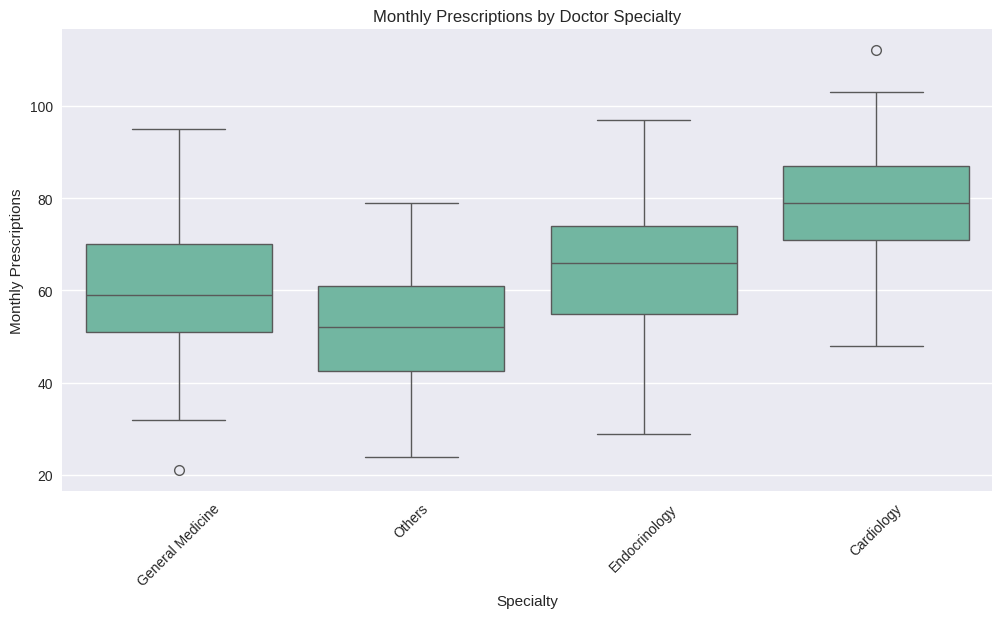

ANOVA Results: F-statistic = 84.4860, p-value = 0.0000
There is a statistically significant difference between specialties.

Tukey HSD Results (pairwise comparisons):
General Medicine vs Others: p-value = 0.0004
General Medicine vs Endocrinology: p-value = 0.0059
General Medicine vs Cardiology: p-value = 0.0000
Others vs Endocrinology: p-value = 0.0000
Others vs Cardiology: p-value = 0.0000
Endocrinology vs Cardiology: p-value = 0.0000


In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='Specialty', y='Monthly_Prescriptions', data=df)
plt.title('Monthly Prescriptions by Doctor Specialty')
plt.xlabel('Specialty')
plt.ylabel('Monthly Prescriptions')
plt.xticks(rotation=45)
plt.show()

# Statistical test - ANOVA
specialty_groups = [df[df['Specialty'] == specialty]['Monthly_Prescriptions']
                   for specialty in df['Specialty'].unique()]

# Performing ANOVA
f_stat, p_value = f_oneway(*specialty_groups)
print(f"ANOVA Results: F-statistic = {f_stat:.4f}, p-value = {p_value:.4f}")

if p_value < 0.05:
    print("There is a statistically significant difference between specialties.")

    # Post-hoc test (Tukey HSD)
    tukey_result = tukey_hsd(*specialty_groups)
    print("\nTukey HSD Results (pairwise comparisons):")

    # Get specialty names for labeling
    specialties = df['Specialty'].unique()

    # Print significant pairwise differences
    for i in range(len(specialties)):
        for j in range(i+1, len(specialties)):
            if tukey_result.pvalue[i, j] < 0.05:
                print(f"{specialties[i]} vs {specialties[j]}: p-value = {tukey_result.pvalue[i, j]:.4f}")
else:
    print("There is no statistically significant difference between specialties.")

### Yes, the specialties of doctors have a significant impact on the number of CardioStat prescriptions they write each month. There are statistically significant differences between certain pairs of specialties in their prescription volumes. The Tukey HSD test results provide insights into which specialties vary from one another significantly.

In [ ]:
# Summary of key findings
print("="*60)
print("SUMMARY OF KEY FINDINGS")
print("="*60)

print("\n1. PRESCRIPTION DISTRIBUTION:")
print(f"   - Average monthly prescriptions: {df['Monthly_Prescriptions'].mean():.2f}")
print(f"   - Range: {df['Monthly_Prescriptions'].min()} to {df['Monthly_Prescriptions'].max()}")
print(f"   - Standard deviation: {df['Monthly_Prescriptions'].std():.2f}")

print("\n2. CITY TIER IMPACT:")
for tier in sorted(df['City_Tier'].unique()):
    avg_rx = df[df['City_Tier'] == tier]['Monthly_Prescriptions'].mean()
    print(f"   - Tier {tier}: {avg_rx:.2f} average prescriptions")

print("\n3. MODEL PERFORMANCE:")
print(f"   - 3-factor model R²: {r2_three_factors:.4f}")
print(f"   - Enhanced model R²: {r2_enhanced:.4f}")
print(f"   - Improvement from adding city tier: {r2_enhanced - r2_three_factors:.4f}")

print("\n4. SIGNIFICANT FACTORS (p < 0.05):")
sig_factors = impact_summary[impact_summary['Significant'] == True]
for factor, coef in sig_factors['Coefficient'].items():
    print(f"   - {factor}: coefficient = {coef:.4f}")

print("\n5. SPECIALTY IMPACT:")
print(f"   - ANOVA p-value: {p_value:.4f}")
if p_value < 0.05:
    print("   - Significant differences exist between specialties")
else:
    print("   - No significant differences between specialties")



SUMMARY OF KEY FINDINGS

1. PRESCRIPTION DISTRIBUTION:
   - Average monthly prescriptions: 65.88
   - Range: 21 to 112
   - Standard deviation: 16.20

2. CITY TIER IMPACT:
   - Tier Tier 1: 65.85 average prescriptions
   - Tier Tier 2: 66.23 average prescriptions
   - Tier Tier 3: 65.39 average prescriptions

3. MODEL PERFORMANCE:
   - 3-factor model R²: 0.1078
   - Enhanced model R²: 0.1084
   - Improvement from adding city tier: 0.0006

4. SIGNIFICANT FACTORS (p < 0.05):
   - Calls_Made: coefficient = 1.0745
   - Samples_Given: coefficient = 0.5999
   - Patients_Per_Week: coefficient = 0.0741

5. SPECIALTY IMPACT:
   - ANOVA p-value: 0.0000
   - Significant differences exist between specialties


# **THANK** **YOU**. THE CASE STUDY IS **COMPLETED**